# Rétropropagation implémentée from scratch en NumPy

**Module :** Machine Learning 2 — ECE Paris, 2025/2026  
**Auteur :** Édouard Menut

Objectif : comprendre ce que font Keras et PyTorch « sous le capot » en codant soi-même, uniquement avec NumPy :

1. une **régression logistique multiclasse** (softmax) entraînée par descente de gradient stochastique ;
2. un **réseau à une couche cachée** avec l'algorithme de **rétropropagation** (règle de la chaîne) ;
3. une étude des hyperparamètres (taille de la couche cachée, taux d'apprentissage, activation) ;
4. une comparaison avec le même réseau construit en Keras.

Jeu de données : **Digits** (1 797 chiffres manuscrits 8×8, 10 classes).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

## Préparation des données

In [2]:
digits = load_digits()
X = np.asarray(digits.data, dtype="float32")
y = np.asarray(digits.target, dtype="int32")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=37)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

n_features, n_classes = X_train.shape[1], 10
print("X_train :", X_train.shape, "| X_test :", X_test.shape)

X_train : (1527, 64) | X_test : (270, 64)


## 1. Briques de base

- **One-hot** : transforme l'étiquette entière en vecteur binaire.
- **Softmax** : transforme les scores (logits) en probabilités. On soustrait le maximum avant l'exponentielle pour la stabilité numérique (évite les débordements avec de grands logits).
- **NLL** (*negative log-likelihood*, entropie croisée) : $-\frac{1}{N}\sum_i \log p(y_i \mid x_i)$. Les probabilités sont bornées par `np.clip` pour éviter $\log(0) = -\infty$.

In [3]:
def one_hot(n_classes, y):
    return np.eye(n_classes)[y]

def softmax(X):
    X = np.asarray(X)
    X_shifted = X - np.max(X, axis=-1, keepdims=True)
    exp_X = np.exp(X_shifted)
    return exp_X / np.sum(exp_X, axis=-1, keepdims=True)

def nll(Y_true, Y_pred):
    Y_true = np.atleast_2d(Y_true)
    Y_pred = np.clip(np.atleast_2d(Y_pred), 1e-12, 1.0 - 1e-12)
    return -np.mean(np.sum(Y_true * np.log(Y_pred), axis=1))

print("one_hot(10, [0, 4, 9]) :\n", one_hot(10, [0, 4, 9]))
print("softmax stable avec de grands logits :", softmax([[1000, 2000, 3000]]).round(3))
print("NLL d'une prédiction confiante mais fausse :", round(nll([1, 0, 0], [0.01, 0.01, 0.98]), 3))
print("NLL de prédictions quasi parfaites :", round(nll([[0, 1, 0], [1, 0, 0]], [[0, 1, 0], [0.99, 0.01, 0]]), 4))

one_hot(10, [0, 4, 9]) :
 [[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]
softmax stable avec de grands logits : [[0. 0. 1.]]
NLL d'une prédiction confiante mais fausse : 4.605
NLL de prédictions quasi parfaites : 0.005


## 2. Régression logistique multiclasse

Modèle linéaire $y = \mathrm{softmax}(xW + b)$. Le gradient de la NLL par rapport aux logits vaut simplement $\hat{y} - y_{\text{one-hot}}$, d'où :
$\nabla_W = x^\top(\hat{y} - y)$ et $\nabla_b = \hat{y} - y$. Les poids sont mis à jour **un exemple à la fois** (SGD).

In [4]:
class LogisticRegression:

    def __init__(self, input_size, output_size):
        self.W = np.random.uniform(-0.1, 0.1, size=(input_size, output_size))
        self.b = np.random.uniform(-0.1, 0.1, size=output_size)
        self.output_size = output_size

    def forward(self, X):
        return softmax(np.dot(X, self.W) + self.b)

    def predict(self, X):
        return np.argmax(self.forward(X), axis=-1)

    def grad_loss(self, x, y_true):
        dnll_output = self.forward(x) - one_hot(self.output_size, y_true)
        return {"W": np.outer(x, dnll_output), "b": dnll_output}

    def train(self, x, y, learning_rate):
        grads = self.grad_loss(x, y)
        self.W -= learning_rate * grads["W"]
        self.b -= learning_rate * grads["b"]

    def loss(self, X, y):
        return nll(one_hot(self.output_size, y), self.forward(X))

    def accuracy(self, X, y):
        return np.mean(self.predict(X) == y)

def plot_prediction(model, sample_idx=0, classes=range(10)):
    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(9, 3))
    ax0.imshow(scaler.inverse_transform(X_test[sample_idx].reshape(1, -1)).reshape(8, 8),
               cmap=plt.cm.gray_r, interpolation="nearest")
    ax0.set_title(f"Vraie classe : {y_test[sample_idx]}")
    ax0.axis("off")
    ax1.bar(classes, one_hot(len(classes), y_test[sample_idx]), label="vraie classe")
    ax1.bar(classes, model.forward(X_test[sample_idx]), label="probabilités prédites", color="red")
    ax1.set_xticks(classes)
    ax1.set_title(f"Prédiction : {model.predict(X_test[sample_idx])}")
    ax1.legend()
    plt.show()

Avant entraînement : loss = 2.430, accuracy test = 0.107
Mise à jour #   0 : loss train = 2.4009, accuracy test = 0.133
Mise à jour # 300 : loss train = 0.6265, accuracy test = 0.911
Mise à jour # 600 : loss train = 0.3945, accuracy test = 0.941
Mise à jour # 900 : loss train = 0.3116, accuracy test = 0.948
Mise à jour #1200 : loss train = 0.2637, accuracy test = 0.970
Mise à jour #1500 : loss train = 0.2289, accuracy test = 0.956
Après 1 epoch : accuracy test = 0.959


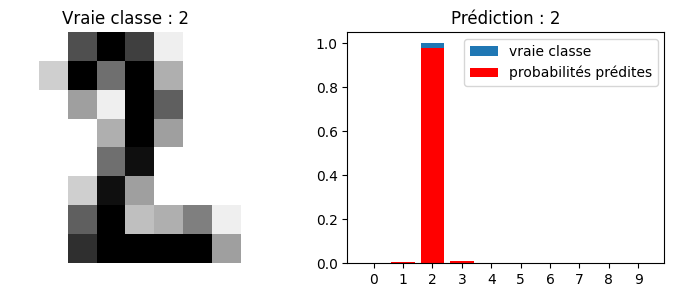

In [5]:
logreg = LogisticRegression(n_features, n_classes)
print(f"Avant entraînement : loss = {logreg.loss(X_train, y_train):.3f}, "
      f"accuracy test = {logreg.accuracy(X_test, y_test):.3f}")

# Une seule epoch de SGD, un exemple à la fois
for i, (x, y_i) in enumerate(zip(X_train, y_train)):
    logreg.train(x, y_i, learning_rate=0.01)
    if i % 300 == 0:
        print(f"Mise à jour #{i:>4} : loss train = {logreg.loss(X_train, y_train):.4f}, "
              f"accuracy test = {logreg.accuracy(X_test, y_test):.3f}")

print(f"Après 1 epoch : accuracy test = {logreg.accuracy(X_test, y_test):.3f}")
plot_prediction(logreg, sample_idx=0)

## 3. Réseau à une couche cachée et rétropropagation

Architecture : $h = \sigma(xW^h + b^h)$ puis $\hat{y} = \mathrm{softmax}(hW^o + b^o)$.

La rétropropagation applique la règle de la chaîne de la sortie vers l'entrée :
- couche de sortie : $\delta^o = \hat{y} - y$, $\nabla_{W^o} = h^\top \delta^o$
- couche cachée : $\delta^h = (W^o \delta^o) \odot \sigma'(z^h)$, $\nabla_{W^h} = x^\top \delta^h$

La classe accepte plusieurs fonctions d'activation (sigmoïde, tanh, ReLU) avec leur dérivée.

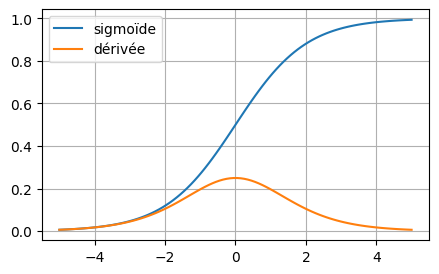

In [6]:
def sigmoid(X):
    return 1.0 / (1.0 + np.exp(-X))

def dsigmoid(X):
    s = sigmoid(X)
    return s * (1.0 - s)

ACTIVATIONS = {
    "sigmoid": (sigmoid, dsigmoid),
    "tanh": (np.tanh, lambda x: 1.0 - np.tanh(x) ** 2),
    "relu": (lambda x: np.maximum(0, x), lambda x: (x > 0).astype(float)),
}

x = np.linspace(-5, 5, 100)
plt.figure(figsize=(5, 3))
plt.plot(x, sigmoid(x), label="sigmoïde")
plt.plot(x, dsigmoid(x), label="dérivée")
plt.legend(); plt.grid(True)
plt.show()

La dérivée de la sigmoïde ne dépasse jamais 0,25 et tend vers 0 pour les grandes valeurs : c'est l'origine du problème de **disparition du gradient** dans les réseaux profonds, qui explique la popularité de ReLU.

In [7]:
class NeuralNet:

    def __init__(self, input_size, hidden_size, output_size, activation="sigmoid"):
        self.W_h = np.random.uniform(-0.1, 0.1, size=(input_size, hidden_size))
        self.b_h = np.random.uniform(-0.1, 0.1, size=hidden_size)
        self.W_o = np.random.uniform(-0.1, 0.1, size=(hidden_size, output_size))
        self.b_o = np.random.uniform(-0.1, 0.1, size=output_size)
        self.output_size = output_size
        self.act, self.dact = ACTIVATIONS[activation]

    def forward_keep_activations(self, X):
        z_h = np.dot(X, self.W_h) + self.b_h
        h = self.act(z_h)
        y = softmax(np.dot(h, self.W_o) + self.b_o)
        return y, h, z_h

    def forward(self, X):
        return self.forward_keep_activations(X)[0]

    def loss(self, X, y):
        return nll(one_hot(self.output_size, y), self.forward(X))

    def grad_loss(self, x, y_true):
        y_pred, h, z_h = self.forward_keep_activations(x)
        dz_o = y_pred - one_hot(self.output_size, y_true)       # gradient sur les logits de sortie
        dz_h = np.dot(self.W_o, dz_o) * self.dact(z_h)          # rétropropagé dans la couche cachée
        return {"W_o": np.outer(h, dz_o), "b_o": dz_o,
                "W_h": np.outer(x, dz_h), "b_h": dz_h}

    def train(self, x, y, learning_rate):
        grads = self.grad_loss(x, y)
        self.W_h -= learning_rate * grads["W_h"]
        self.b_h -= learning_rate * grads["b_h"]
        self.W_o -= learning_rate * grads["W_o"]
        self.b_o -= learning_rate * grads["b_o"]

    def predict(self, X):
        return np.argmax(self.forward(X), axis=-1)

    def accuracy(self, X, y):
        return np.mean(self.predict(X) == y)

Après 15 epochs : loss = 0.0181, accuracy train = 0.999, test = 0.959


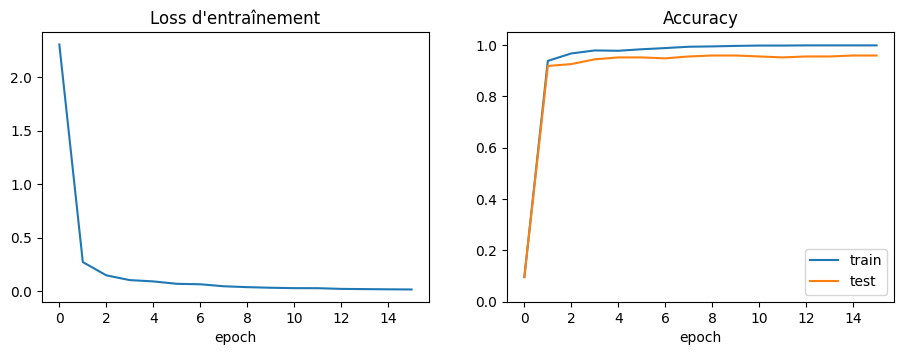

In [8]:
model = NeuralNet(n_features, 10, n_classes)
losses = [model.loss(X_train, y_train)]
acc_train = [model.accuracy(X_train, y_train)]
acc_test = [model.accuracy(X_test, y_test)]

for epoch in range(15):
    for x, y_i in zip(X_train, y_train):
        model.train(x, y_i, learning_rate=0.1)
    losses.append(model.loss(X_train, y_train))
    acc_train.append(model.accuracy(X_train, y_train))
    acc_test.append(model.accuracy(X_test, y_test))

print(f"Après 15 epochs : loss = {losses[-1]:.4f}, accuracy train = {acc_train[-1]:.3f}, test = {acc_test[-1]:.3f}")

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 3.5))
ax0.plot(losses); ax0.set_title("Loss d'entraînement"); ax0.set_xlabel("epoch")
ax1.plot(acc_train, label="train"); ax1.plot(acc_test, label="test")
ax1.set_ylim(0, 1.05); ax1.set_title("Accuracy"); ax1.set_xlabel("epoch"); ax1.legend()
plt.show()

### Analyse des pires erreurs

On cherche les images de test pour lesquelles le modèle entraîné attribue la plus faible probabilité à la vraie classe (NLL la plus élevée).

Indices des 3 pires prédictions : [170 219  87]


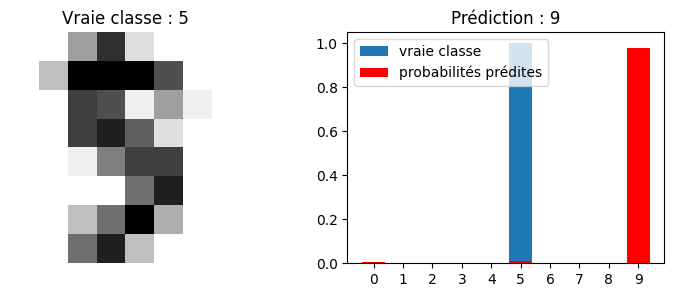

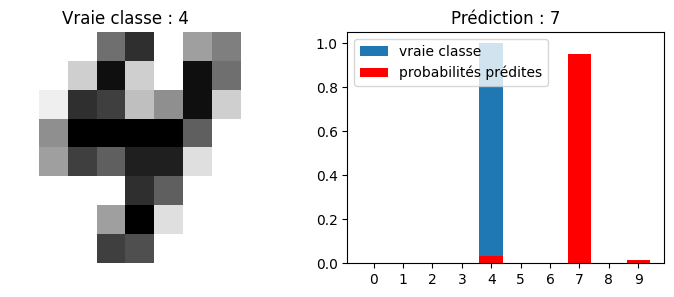

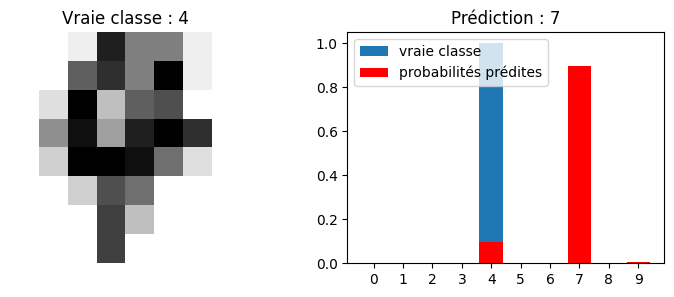

In [9]:
nll_per_sample = -np.log(np.clip(model.forward(X_test)[np.arange(len(y_test)), y_test], 1e-12, 1))
worst = np.argsort(nll_per_sample)[-3:][::-1]
print("Indices des 3 pires prédictions :", worst)
for idx in worst:
    plot_prediction(model, sample_idx=idx)

Les erreurs restantes concernent des chiffres ambigus même pour un humain à cette résolution (8×8 pixels) : le modèle se trompe sur des cas réellement difficiles.

## 4. Étude des hyperparamètres

Une epoch de SGD pour chaque combinaison de taille de couche cachée, de taux d'apprentissage et d'activation.

In [10]:
results = []
for hidden in [16, 32, 64]:
    for lr in [0.01, 0.05, 0.1]:
        for act in ACTIVATIONS:
            np.random.seed(0)
            nn = NeuralNet(n_features, hidden, n_classes, activation=act)
            for x, y_i in zip(X_train, y_train):
                nn.train(x, y_i, learning_rate=lr)
            results.append({"couche cachée": hidden, "learning rate": lr, "activation": act,
                            "accuracy test": nn.accuracy(X_test, y_test)})

res = pd.DataFrame(results).pivot_table(index=["couche cachée", "learning rate"],
                                        columns="activation", values="accuracy test")
res.round(3)

activation                    relu  sigmoid   tanh
couche cachée learning rate                       
16            0.01           0.907    0.441  0.919
              0.05           0.907    0.911  0.956
              0.10           0.467    0.926  0.907
32            0.01           0.948    0.674  0.944
              0.05           0.930    0.919  0.956
              0.10           0.689    0.937  0.933
64            0.01           0.944    0.752  0.941
              0.05           0.922    0.904  0.933
              0.10           0.707    0.919  0.922

- **tanh** est la plus robuste : ≥ 90 % dans toutes les configurations, jusqu'à 95,6 % en une seule epoch.
- **sigmoïde** apprend lentement avec un petit taux d'apprentissage (44 à 75 % à lr = 0,01) : ses gradients sont faibles (dérivée ≤ 0,25).
- **ReLU** est excellente avec un petit taux (jusqu'à 94,8 %) mais diverge avec lr = 0,1 : sans borne supérieure, les activations et les mises à jour deviennent trop grandes.

Le taux d'apprentissage optimal dépend donc de la fonction d'activation.

## 5. Le même réseau en Keras

On reproduit l'architecture (32 neurones sigmoïde, sortie softmax, SGD avec momentum) et on vérifie que la NLL calculée à la main correspond à la loss reportée par Keras.

NLL de l'échantillon de test n°42 : 0.0007
NLL moyenne train (calcul manuel) : 0.0111 | loss Keras : 0.0111
NLL moyenne test : 0.0746


Accuracy train : 1.000 | test : 0.970


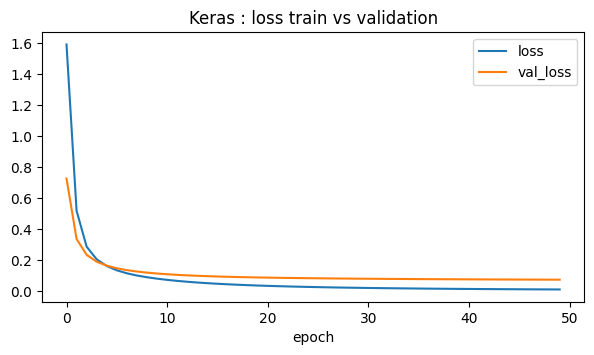

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.utils import to_categorical
import tensorflow as tf

tf.random.set_seed(42)
y_train_oh = to_categorical(y_train, num_classes=n_classes)
y_test_oh = to_categorical(y_test, num_classes=n_classes)

keras_model = Sequential([
    Input(shape=(n_features,)),
    Dense(32, activation="sigmoid"),
    Dense(n_classes, activation="softmax"),
])
keras_model.compile(optimizer=SGD(learning_rate=0.05, momentum=0.9),
                    loss="categorical_crossentropy", metrics=["accuracy"])
history = keras_model.fit(X_train, y_train_oh, validation_data=(X_test, y_test_oh),
                          epochs=50, batch_size=32, verbose=0)

p_train = keras_model.predict(X_train, verbose=0)
p_test = keras_model.predict(X_test, verbose=0)
print(f"NLL de l'échantillon de test n°42 : {nll(y_test_oh[42], p_test[42]):.4f}")
print(f"NLL moyenne train (calcul manuel) : {nll(y_train_oh, p_train):.4f} | "
      f"loss Keras : {keras_model.evaluate(X_train, y_train_oh, verbose=0)[0]:.4f}")
print(f"NLL moyenne test : {nll(y_test_oh, p_test):.4f}")
print(f"Accuracy train : {keras_model.evaluate(X_train, y_train_oh, verbose=0)[1]:.3f} | "
      f"test : {keras_model.evaluate(X_test, y_test_oh, verbose=0)[1]:.3f}")

pd.DataFrame(history.history)[["loss", "val_loss"]].plot(figsize=(7, 3.5), title="Keras : loss train vs validation")
plt.xlabel("epoch"); plt.show()

La NLL calculée à la main est identique à la loss de Keras (0,0111) : l'implémentation NumPy est validée.

Le modèle Keras atteint 100 % sur le train et 97 % sur le test, avec une loss de validation qui remonte légèrement en fin d'entraînement : c'est un **léger sur-apprentissage**, qu'un EarlyStopping ou une régularisation L2 limiterait.

## Conclusion

| Modèle | Accuracy test |
|---|---|
| Régression logistique NumPy (1 epoch) | 95,9 % |
| Réseau 1 couche cachée NumPy (15 epochs) | 95,9 % |
| Même architecture en Keras (SGD + momentum, 50 epochs) | 97,0 % |

Implémenter la rétropropagation à la main permet de comprendre précisément le rôle de chaque hyperparamètre, et de vérifier qu'un framework comme Keras calcule exactement la même chose.